In [ ]:
#import
import rasterio
import os
import numpy as np
import pandas as pd
import glob
from osgeo import gdal
import rioxarray as rxr
import matplotlib.pyplot as plt
import fiona
import rasterio.mask
from datetime import datetime


#from scripts.raster_prep_copy import out_dir


In [ ]:
# set directory
dir = "C:/Users/RDCRLSMC/Desktop/SIRO/Task1/dates/2023/20230405"

In [ ]:
lidar = glob.glob(os.path.join(dir, "lidar","*.tif"))
print(lidar)

# Split by underscore and pick the part that looks like a date
parts = os.path.basename(lidar[0]).split("_")
for part in parts:
    if part.isdigit() and len(part) == 8:
        date_str = part
        break

print(date_str)

date_obj = datetime.strptime(date_str, "%Y%m%d")
print(date_obj)

In [ ]:
modeled = os.path.join(dir, "modeled")

In [ ]:

HMS_EB = glob.glob(os.path.join(modeled, "*EB_snow_depth*.tif"))[0]
HMS_TI = glob.glob(os.path.join(modeled, "*TI_snow_depth*.tif"))[0]

with rasterio.open(HMS_EB) as src:
    raster_data = src.read(1, masked=True).filled(np.nan)
    out_raster = raster_data * 0.0254
                # Include model in output filename
    out_path = os.path.join(modeled, "HMS_EB_inches.tif")
    profile = src.profile
    profile.update(
        dtype=rasterio.float32,
        nodata= -9999
    )
    with rasterio.open(out_path, "w", **profile) as dest:
            dest.write(out_raster.astype("float32"), 1)

with rasterio.open(HMS_TI) as src:
    raster_data = src.read(1, masked=True).filled(np.nan)
    out_raster = raster_data * 0.0254
                # Include model in output filename
    out_path = os.path.join(modeled, "HMS_TI_inches.tif")
    profile = src.profile
    profile.update(
        dtype=rasterio.float32,
        nodata= -9999
    )
    with rasterio.open(out_path, "w", **profile) as dest:
            dest.write(out_raster.astype("float32"), 1)



In [ ]:
rasters = {
    "HMS_EB": glob.glob(os.path.join(modeled, "*EB_inches*.tif")),
    "HMS_TI": glob.glob(os.path.join(modeled, "*TI_inches*.tif")),
    "iSnobal": glob.glob(os.path.join(modeled, "*thickness*.tif")),
    "SnowModel": glob.glob(os.path.join(modeled, "*snod*.tif")),
}

print(rasters)

In [ ]:
MCS = os.path.join(dir, "MCS_outline/basin_outline.shp")

with fiona.open(MCS, "r") as shapefile:
    shapes = [feature["geometry"] for feature in shapefile]

In [ ]:
out_dir = os.path.join(dir, "outputs")
stats_list = []

# Loop by model
for model, raster_list in rasters.items():
    for raster in raster_list:
        with rasterio.open(raster) as src:
            out_image, out_transform = rasterio.mask.mask(src, shapes, crop=True)
            out_meta = src.meta.copy()

        out_meta.update({
            "driver": "GTiff",
            "height": out_image.shape[1],
            "width": out_image.shape[2],
            "transform": out_transform,
        })

        # Include model in output filename
        out_name = f"{model}_MCS.tif"
        out_path = os.path.join(out_dir, out_name)

        with rasterio.open(out_path, "w", **out_meta) as dest:
            dest.write(out_image)

# Compute statistics
        data = out_image[0]  # 1 band raster, extract 2D array
        mask = (data == -9999)
        data_masked = np.ma.array(data, mask=mask)  # mask nodata

        raster_stats = {
            "file": out_name,
            "model": model,
            "min": data_masked.min(),
            "mean": data_masked.mean(),
            "max": data_masked.max(),
            "zeros": np.sum(data_masked == 0)
        }
        
        stats_list.append(raster_stats)


# Convert stats to a DataFrame
stats_df = pd.DataFrame(stats_list)
stats_csv = os.path.join(out_dir, "raster_stats.csv")
stats_df.to_csv(stats_csv, index=False)


In [ ]:
outputs = os.path.join(dir, "outputs")

rasters = {
    "HMS Energy Balance": glob.glob(os.path.join(outputs, "*EB*.tif")),
    "HMS Temperature Index": glob.glob(os.path.join(outputs, "*TI*.tif")),
    "iSnobal": glob.glob(os.path.join(outputs, "*iSnobal*.tif")),
    "SnowModel": glob.glob(os.path.join(outputs, "*SnowModel*.tif")),
}

In [ ]:
# Pick the first raster from each model (for plotting)
fig, axes = plt.subplots(2, 2, figsize=(8, 10))
axes = axes.flatten()  # flatten to 1D array for easy looping

for i, (model, raster_list) in enumerate(rasters.items()):
    raster_path = raster_list[0] 
    
    with rasterio.open(raster_path) as src:
        data = src.read(1, masked=True)  # read first band, mask NoData
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    
    im = axes[i].imshow(data, cmap="viridis", extent=extent, vmin=0,vmax=4.0 )
    axes[i].set_title(model)
    axes[i].axis("off")

# Add colorbar
fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, label="Snow Depth")
fig.suptitle(f"Mores Creek Snow Depth, {date_obj.strftime('%B %d, %Y')}", fontsize=16,  y=0.95)

fig.subplots_adjust(
    wspace=0.05,
    hspace=0.06,
    right=0.88
    #top=0.90
)

plt.savefig(os.path.join(outputs, "Basin_models.png"), dpi=300, bbox_inches="tight")

plt.show()



In [ ]:
dfs = []

for model, raster_list in rasters.items():
    for raster in raster_list:
        with rasterio.open(raster) as src:
            data = src.read(1, masked=True)
            mask = (data == -9999)
            data_masked = np.ma.array(data, mask=mask)  # mask nodata
            flattened = data_masked.compressed()
            
        # convert to DataFrame
            df = pd.DataFrame({
            "Model": model,        # this column will store model names
            "value": flattened     # this column stores raster values
        })
        dfs.append(df)

all_data = pd.concat(dfs, ignore_index=True)

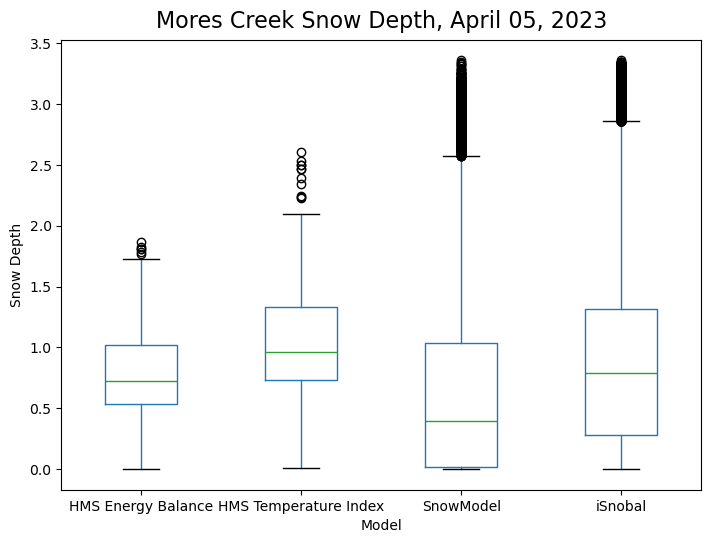

In [223]:
fig, ax = plt.subplots(figsize=(8, 6))
all_data.boxplot(column="value", by="Model", ax=ax, grid=False)

# Remove the default 'by' title
ax.set_title("")  

# Figure-level title
fig.suptitle(f"Mores Creek Snow Depth, {date_obj.strftime('%B %d, %Y')}", fontsize=16, y=0.95)
ax.set_ylabel("Snow Depth")

plt.savefig(os.path.join(outputs, "raster_boxplot.png"), dpi=300, bbox_inches="tight")
plt.show()


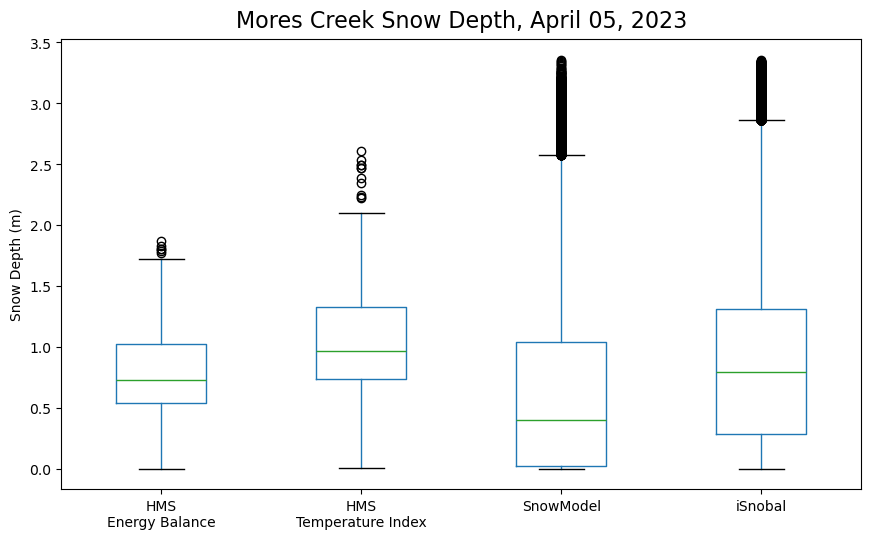

In [226]:
fig, ax = plt.subplots(figsize=(10, 6))

# Suppose your DataFrame has a column "Model" with long names
all_data.boxplot(column="value", by="Model", ax=ax, grid=False)

# Remove pandas' default title
ax.set_title("")

# Create multi-line labels by inserting '\n'
labels = [label.get_text() for label in ax.get_xticklabels()]
new_labels = []
for lbl in labels:
    if len(lbl) > 12:  # arbitrarily split long labels
        # split in half
        mid = len(lbl) // 2
        # find nearest space to split
        space_idx = lbl.rfind(" ", 0, mid)
        if space_idx == -1:
            space_idx = mid
        lbl = lbl[:space_idx] + "\n" + lbl[space_idx:].strip()
    new_labels.append(lbl)

ax.set_xticklabels(new_labels)

# Figure-level title
fig.suptitle(f"Mores Creek Snow Depth, {date_obj.strftime('%B %d, %Y')}", fontsize=16, y=0.95)

ax.set_ylabel("Snow Depth (m)")
ax.set_xlabel("")

#plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.savefig(os.path.join(outputs, "raster_boxplot.png"), dpi=300, bbox_inches="tight")
plt.show()
